# Earthquake catalogues: Gutenberg-Richter and ETAS

We simulate catalogues with:
- truncated Gutenberg-Richter magnitudes;
- background epicentres that are uniform on the sphere, plus tectonic
  hotspots;
- ETAS-style aftershock cascades with Omori-Utsu decay.

We then recover the b-value and the Omori parameters.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pcc_vizforge.plots.style import apply_matplotlib_style

apply_matplotlib_style()
SEED = 20240101

In [2]:
from pcc_vizforge.generators import EarthquakeGenerator
from pcc_vizforge.generators.quakes import branching_ratio
from pcc_vizforge.analysis import seismology

gen = EarthquakeGenerator(n_earthquakes=5000, b_value=1.0,
                          aftershocks={"enabled": True, "productivity": 0.05, "alpha": 0.8})
cat = gen.generate(seed=SEED)
p, a = gen.params, gen.params.aftershock_cfg
n_br = branching_ratio(p.b_value, a["alpha"], a["productivity"], *p.magnitude_range)
print(f"{len(cat)} events, {cat.is_aftershock.sum()} aftershocks; branching ratio n = {n_br:.3f}")
print(f"expected catalogue size N0/(1-n) = {5000 / (1 - n_br):.0f} (for an infinitely long window)")

6237 events, 1237 aftershocks; branching ratio n = 0.237
expected catalogue size N0/(1-n) = 6557 (for an infinitely long window)


The catalogue is smaller than $N_0/(1-n)$ because aftershocks that would occur after the one-year window are never observed. The Omori tail with $p \approx 1.1$ is long.

## Frequency-magnitude distribution

BValueEstimate(b_value=1.0125707621951459, a_value=5.8201172684414235, std_error=0.012757389542198896, ci=(0.9875667381556881, 1.0375747862346036), n_events=6237, mc=2.0, method='aki-utsu')
unbiased: 1.0124
Mc (max curvature): 2.3000000000000003


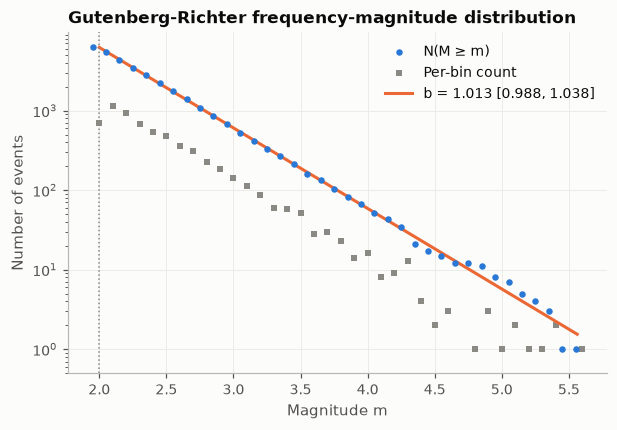

In [3]:
from pcc_vizforge.plots import diagnostics as D

est = seismology.b_value_mle(cat["magnitude"], 2.0)
D.gutenberg_richter_figure(cat["magnitude"], est)
print(est)
print("unbiased:", round(seismology.b_value_mle(cat["magnitude"], 2.0, unbiased=True).b_value, 4))
print("Mc (max curvature):", seismology.magnitude_of_completeness(cat["magnitude"]))

## Aftershock decay

Delays between each aftershock and its parent follow the Omori-Utsu law $\propto (t+c)^{-p}$.

naive (one common window): p = 1.143 ± 0.015
per-parent windows:        p = 1.088 ± 0.015 (true 1.1), c = 0.0093 d (true 0.01)


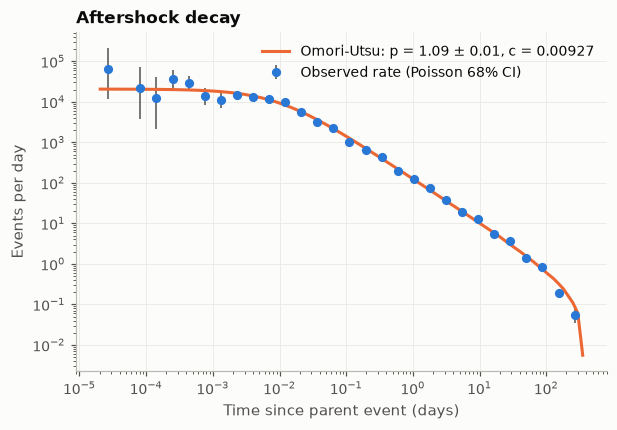

In [4]:
delays, windows = gen.aftershock_delays(cat)   # windows = catalogue end - parent time
naive = seismology.fit_omori(delays)
omori = seismology.fit_omori(delays, windows)
print(f"naive (one common window): p = {naive.p:.3f} ± {naive.p_stderr:.3f}")
print(f"per-parent windows:        p = {omori.p:.3f} ± {omori.p_stderr:.3f} (true {a['omori_p']}), "
      f"c = {omori.c:.4f} d (true {a['omori_c_days']})")
D.omori_figure(delays, omori, windows=windows);

Pooling delays from parents that occur at different times censors long delays unevenly. Ignoring this steepens the fitted decay, so the fit must normalise each delay over its own observation window.

## Temporal clustering

The coefficient of variation of inter-event times is 1 for a Poisson process and greater than 1 when events cluster.

In [5]:
poisson = EarthquakeGenerator(n_earthquakes=5000, aftershocks={"enabled": False}).generate(seed=SEED)
print("CV with aftershocks:", round(seismology.interevent_cv(cat.time_days), 3))
print("CV Poisson background:", round(seismology.interevent_cv(poisson.time_days), 3))

CV with aftershocks: 1.066
CV Poisson background: 1.025


## Where the Aki estimator breaks: a narrow magnitude range

In [6]:
from pcc_vizforge.rng import make_rng

m = seismology.truncated_gr_sample(make_rng(SEED), 20_000, 1.0, 2.0, 3.0)
print("Aki (assumes no Mmax):", round(seismology.b_value_mle(m, 2.0).b_value, 3))
print("Page (truncated MLE):  ", round(seismology.b_value_mle_truncated(m, 2.0, 3.0).b_value, 3))

Aki (assumes no Mmax): 1.333
Page (truncated MLE):   0.983
